# Algoritmo de Grover

El algoritmo de Grover resuelve un problema de búsqueda en una base de datos no estructurada de tamaño $N=2^n$. Suponemos que existe un único estado marcado $\ket{j_0}$, y el objetivo es encontrarlo con alta probabilidad.

El algoritmo empieza preparando la superposición uniforme

$$
\ket{\gamma}
=
\frac{1}{\sqrt{N}}\sum_{j=0}^{N-1}\ket{j}.
$$

Luego se repite una iteración de Grover, compuesta por dos partes:

1. **Oráculo:** cambia el signo del estado marcado.
   $$
   \ket{j_0}\mapsto -\ket{j_0}.
   $$

2. **Difusor:** refleja el estado alrededor de la superposición uniforme.
   $$
   \Gamma = 2\ket{\gamma}\bra{\gamma}-I.
   $$

Estas dos reflexiones amplifican la amplitud del estado marcado. Para una única solución, el número adecuado de iteraciones es aproximadamente

$$
m\approx \frac{\pi}{4}\sqrt{N}.
$$



In [29]:
# !pip install qiskit

In [30]:
import numpy as np

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from IPython.display import display

## Compuerta multi-controlada $Z$

Primero implementamos una compuerta $Z$ multi-controlada. Esta compuerta cambia el signo del estado $\ket{11\cdots 1}$.

Para construirla usamos la identidad 

$$
MCZ = H \cdot MCX \cdot H
$$

sobre el último qubit, donde MXC es Multi-Controlled X

In [31]:
def apply_multi_controlled_z(circuit: QuantumCircuit, num_qubits: int) -> None:
    """
    Aplica una compuerta Z multi-controlada. que hace |11...1> -> -|11...1>
    y deja los demás estados iguales.
    """
    if num_qubits == 1:
        circuit.z(0)
        return

    target = num_qubits - 1
    controls = list(range(num_qubits - 1))

    circuit.h(target)
    circuit.mcx(controls, target)
    circuit.h(target)

## Oráculo de fase

El oráculo debe marcar un estado específico. Para marcar, por ejemplo, $\ket{101}$, primero convertimos ese estado en $\ket{111}$ usando compuertas $X$ sobre los bits que son cero.

Luego aplicamos la compuerta $Z$ multi-controlada, que cambia el signo de $\ket{111}$. Finalmente deshacemos las compuertas $X$.

Así, el estado marcado cambia de signo y los demás quedan iguales.

In [32]:
def phase_oracle(marked_state: str) -> QuantumCircuit:
    """
    Oráculo de fase que cambia el signo del estado marcado.
    """
    if not marked_state or any(bit not in "01" for bit in marked_state):
        raise ValueError("marked_state debe ser una cadena binaria no vacía.")

    num_qubits = len(marked_state)
    oracle = QuantumCircuit(num_qubits, name=f"O_{marked_state}")

    for qubit, bit in enumerate(reversed(marked_state)):
        if bit == "0":
            oracle.x(qubit)

    apply_multi_controlled_z(oracle, num_qubits)

    for qubit, bit in enumerate(reversed(marked_state)):
        if bit == "0":
            oracle.x(qubit)

    return oracle

## Difusor

El difusor implementa la reflexión alrededor de la superposición uniforme:

$$
\Gamma = 2\ket{\gamma}\bra{\gamma}-I.
$$

Operacionalmente se construye como

$$
H^{\otimes n}X^{\otimes n}MCZ X^{\otimes n}H^{\otimes n},
$$

junto con una fase global para que coincida exactamente con la convención teórica.

In [33]:
def diffuser(num_qubits: int) -> QuantumCircuit:
    """
    Difusor de Grover.
    """
    diffusion = QuantumCircuit(num_qubits, name="D")

    diffusion.h(range(num_qubits))
    diffusion.x(range(num_qubits))

    apply_multi_controlled_z(diffusion, num_qubits)

    diffusion.x(range(num_qubits))
    diffusion.h(range(num_qubits))

    # Esta fase global hace que el operador coincida con 2|gamma><gamma| - I.
    diffusion.global_phase += np.pi

    return diffusion

## Número de iteraciones

Para una única solución, si $N=2^n$, tomamos $\theta$ tal que

$$
\sin^2(\theta)=\frac{1}{N}.
$$

La probabilidad de medir el estado marcado se maximiza cuando

$$
(2m+1)\theta \approx \frac{\pi}{2}.
$$

Por eso usamos aproximadamente

$$
m \approx \frac{\pi}{4\theta}.
$$

In [34]:
def grover_iterations(num_qubits: int, num_marked: int = 1) -> int:
    """
    Calcula un número adecuado de iteraciones de Grover.

    Para una única solución:
    sin^2(theta) = 1/N.

    Para t soluciones:
    sin^2(theta) = t/N.
    """
    search_space = 2 ** num_qubits

    if not (1 <= num_marked <= search_space):
        raise ValueError("num_marked debe estar entre 1 y 2**num_qubits.")

    theta = np.arcsin(np.sqrt(num_marked / search_space))

    return max(1, int(np.floor(np.pi / (4 * theta))))

## Circuito de Grover

Ahora construimos el circuito completo. Primero aplicamos Hadamard a todos los qubits para preparar la superposición uniforme. Luego aplicamos varias veces la iteración de Grover:

$$
G = D O_f,
$$

donde $O_f$ es el oráculo y $D$ es el difusor.

In [35]:
def grover_circuit(
    marked_state: str,
    iterations: int | None = None
) -> tuple[QuantumCircuit, int]:
    """
    Construye el circuito de Grover para un único estado marcado.
    """
    num_qubits = len(marked_state)

    if iterations is None:
        iterations = grover_iterations(num_qubits, num_marked=1)

    circuit = QuantumCircuit(num_qubits, name="Grover")

    # Preparar la superposición uniforme.
    circuit.h(range(num_qubits))

    oracle = phase_oracle(marked_state)
    diffusion = diffuser(num_qubits)

    for _ in range(iterations):
        circuit.append(oracle.to_gate(), range(num_qubits))
        circuit.append(diffusion.to_gate(), range(num_qubits))

    return circuit, iterations

Oráculo:


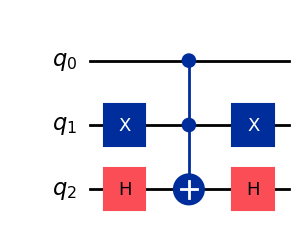

Difusor:


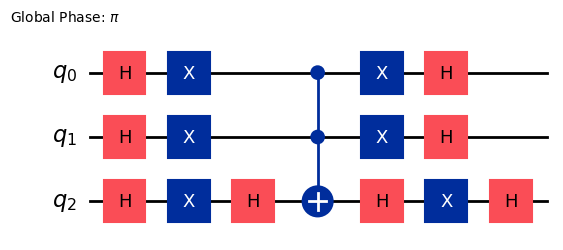

Circuito completo de Grover:


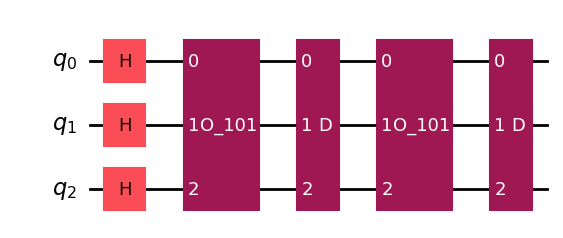

In [36]:
marked_state = "101"
num_qubits = len(marked_state)

oracle = phase_oracle(marked_state)
diffusion = diffuser(num_qubits)
circuit, iterations = grover_circuit(marked_state)

print("Oráculo:")
display(oracle.draw("mpl", fold=-1))

print("Difusor:")
display(diffusion.draw("mpl", fold=-1))

print("Circuito completo de Grover:")
display(circuit.draw("mpl", fold=-1))

## Simulación

Simulamos el circuito usando `Statevector`. Después de aplicar Grover, la probabilidad del estado marcado debe ser la más alta.

In [37]:
state = Statevector.from_instruction(circuit)

probabilities = state.probabilities_dict()
counts = state.sample_counts(shots=1024)

print(f"Estado marcado: |{marked_state}>")
print(f"Iteraciones usadas: {iterations}")

print("\nProbabilidades más altas:")
for bitstring, probability in sorted(
    probabilities.items(),
    key=lambda item: item[1],
    reverse=True
)[:4]:
    print(f"|{bitstring}>: {probability:.4f}")

print("\nMuestras simuladas:")
print(counts)

assert max(counts, key=counts.get) == marked_state

Estado marcado: |101>
Iteraciones usadas: 2

Probabilidades más altas:
|101>: 0.9453
|011>: 0.0078
|001>: 0.0078
|010>: 0.0078

Muestras simuladas:
{np.str_('000'): np.int64(6), np.str_('001'): np.int64(5), np.str_('010'): np.int64(8), np.str_('011'): np.int64(7), np.str_('100'): np.int64(11), np.str_('101'): np.int64(971), np.str_('110'): np.int64(7), np.str_('111'): np.int64(9)}


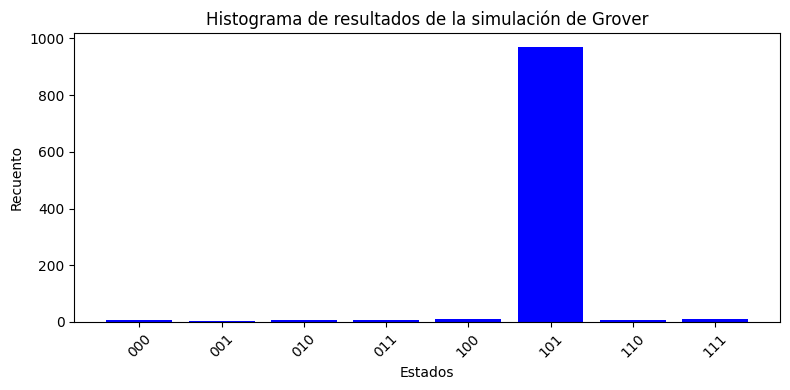

In [39]:
import matplotlib.pyplot as plt

bitstrings = list(counts.keys())
frecuencias = list(counts.values())

plt.figure(figsize=(8, 4))
plt.bar(bitstrings, frecuencias, color="blue")
plt.xlabel("Estados")
plt.ylabel("Recuento")
plt.title("Histograma de resultados de la simulación de Grover")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()